# Repository Recommender - Data Exploration & Baseline Model

This notebook demonstrates the DS workflow for the git-query recommender:
1. Load repository dataset from the gateway API
2. Explore data distributions
3. Extract features for ranking
4. Train a baseline ranking model
5. Evaluate with IR metrics

In [45]:
import sys
sys.path.insert(0, '../../..')  # Add project root to path

import os
from dotenv import load_dotenv
load_dotenv(dotenv_path='../../../.env')  # Load .env from project root

from src.recommender.data import RepoDataset, FeatureExtractor
import pandas as pd
import numpy as np
import fastparquet
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import ndcg_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import joblib
import os

In [46]:
# Simple EDA + Feature Extraction (keep non-numeric info in engineered features)

# Basic cleaning and engineered fields
df = df.copy()  # avoid mutating original unexpectedly
df['readme'] = df.get('readme', '').fillna('').astype(str)
df['has_readme'] = df['readme'].str.strip().astype(bool).astype(int)
df['readme_word_count'] = df['readme'].apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
df['readme_char_count'] = df['readme'].apply(lambda s: len(s) if isinstance(s, str) else 0)

# Topics -> topics_count
if 'topics' in df.columns:
    df['topics'] = df['topics'].apply(lambda t: t if isinstance(t, list) else [])
    df['topics_count'] = df['topics'].apply(len)
else:
    df['topics_count'] = 0

# Dates: parse consistently as UTC-aware, then compute recency in days
date_cols = ['pushed_at','updated_at','created_at','last_push_at']
for col in date_cols:
    if col in df.columns:
        parsed = pd.to_datetime(df[col], errors='coerce', utc=True)
        df[col] = parsed
# compute days_since_push using UTC-aware now if pushed_at exists
now_utc = pd.Timestamp.now(tz='UTC')
if 'pushed_at' in df.columns:
    df['days_since_push'] = ((now_utc - df['pushed_at']).dt.total_seconds() / 86400).round(2)
else:
    df['days_since_push'] = np.nan

# Numeric conversions for engagement signals
for col in ['stars','forks','open_issues','watchers','contributors']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Basic EDA outputs
print('\nMissing values (top):')
print(df.isna().sum().sort_values(ascending=False).head(20))

if 'language' in df.columns:
    print('\nTop languages:')
    print(df['language'].fillna('missing').value_counts().head(20))
if 'license' in df.columns:
    print('\nTop licenses:')
    print(df['license'].fillna('missing').value_counts().head(20))


Missing values (top):
parent               1000
codeOfConduct         546
language              104
primaryLanguage       104
license                89
description             6
created_at              0
full_name               0
repo_id                 0
is_fork                 0
is_archived             0
_id                     0
nameWithOwner           0
topics_list             0
topics_str              0
readme                  0
has_readme              0
readme_word_count       0
readme_char_count       0
days_since_push         0
dtype: int64

Top languages:
language
Python              191
TypeScript          156
JavaScript          130
missing             104
Go                   74
Java                 50
C++                  47
Rust                 45
C                    24
Jupyter Notebook     22
Shell                19
HTML                 18
C#                   12
Kotlin               11
Ruby                 10
Swift                 9
CSS                   8
Vue        

In [47]:
# Build features DataFrame (keep numeric base + light encodings for non-numeric)
base_numeric = ['stars','forks','watchers','contributors','days_since_push','has_readme','readme_word_count','readme_char_count','topics_count']
for c in base_numeric:
    if c not in df.columns:
        df[c] = 0
features = df[base_numeric].copy()

# Keep simple categorical columns (fill missing)
if 'language' in df.columns:
    features['language'] = df['language'].fillna('missing').astype(str)
if 'license' in df.columns:
    features['license'] = df['license'].fillna('missing').astype(str)

# TF-IDF on README -> reduce with SVD to a small set of numeric features
tfidf = TfidfVectorizer(max_features=200, stop_words='english')
if df['readme'].str.strip().astype(bool).any():
    X_tfidf = tfidf.fit_transform(df['readme'].fillna(''))
    n_comp = min(10, max(1, X_tfidf.shape[1]))
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    X_svd = svd.fit_transform(X_tfidf)
    for i in range(X_svd.shape[1]):
        features[f'readme_svd_{i}'] = X_svd[:, i]
    # top term (cheap categorical signal) - keep only top K terms later
    terms = tfidf.get_feature_names_out()
    top_idx = X_tfidf.argmax(axis=1).A1
    features['readme_top_term'] = [terms[i] if i < len(terms) else '' for i in top_idx]
else:
    # no readme text available; add zero SVD features
    for i in range(10):
        features[f'readme_svd_{i}'] = 0.0
    features['readme_top_term'] = ''
    tfidf = None
    svd = None

Saved engineered features to data/features_engineered.csv
Saved TF-IDF/SVD artifacts to models/ (if created)


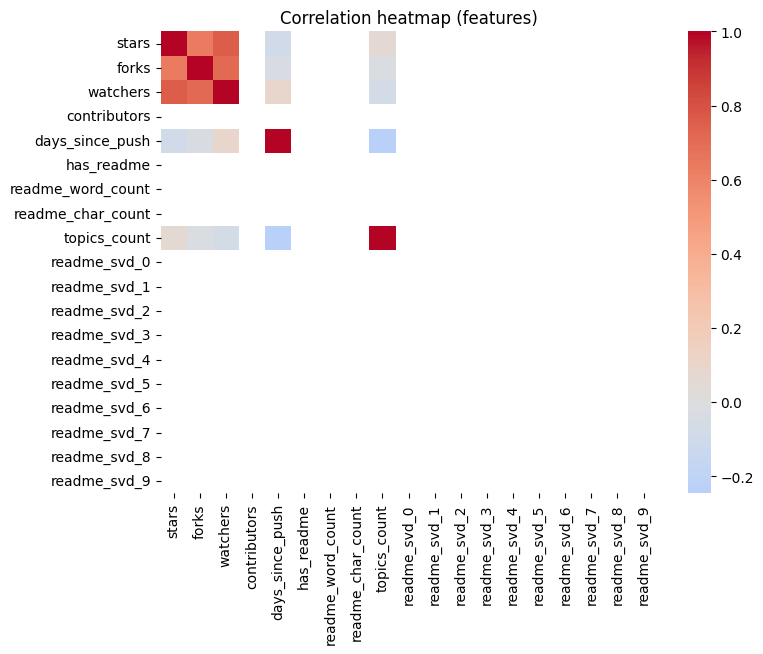


Features shape: (1000, 22)
Train: (800, 19), Test: (200, 19)


In [48]:
# Save engineered features and lightweight artefacts
os.makedirs('data', exist_ok=True)
features.to_csv('data/features_engineered.csv', index=False)
print('Saved engineered features to data/features_engineered.csv')
os.makedirs('models', exist_ok=True)
if tfidf is not None:
    joblib.dump(tfidf, 'models/tfidf_vectorizer.joblib')
if 'svd' in locals() and svd is not None:
    joblib.dump(svd, 'models/readme_svd.joblib')
print('Saved TF-IDF/SVD artifacts to models/ (if created)')

# Quick correlation heatmap for numeric features
num_cols = features.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
    corr = features[num_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation heatmap (features)')
    plt.show()

print('\nFeatures shape:', features.shape)
features.head()

# Categorical handling: keep only top-K values for high-cardinality columns
# readme_top_term may be high-cardinality; collapse to top 20 terms
TOP_K = 20
if 'readme_top_term' in features.columns:
    top_terms = features['readme_top_term'].value_counts().index[:TOP_K].tolist()
    features['readme_top_term_trimmed'] = features['readme_top_term'].apply(lambda x: x if x in top_terms else 'other')
else:
    features['readme_top_term_trimmed'] = 'missing'

# One-hot encode low-cardinality categoricals using get_dummies (language, license, readme_top_term_trimmed)
cat_cols = [c for c in ['language','license','readme_top_term_trimmed'] if c in features.columns]
if cat_cols:
    features_encoded = pd.get_dummies(features, columns=cat_cols, dummy_na=False, drop_first=False)
else:
    features_encoded = features.copy()

# Final feature matrix for modeling - drop original object columns if any remain
X = features_encoded.select_dtypes(include=[np.number]).fillna(0)
# If a relevance vector exists, reuse it; else create synthetic using first test query
if 'relevance' in globals():
    y = relevance.fillna(0)
else:
    # create relevance from first query (if available)
    test_queries = globals().get('test_queries', ['python machine learning'])
    q = test_queries[0]
    y = FeatureExtractor().topic_overlap(df, q.split()).fillna(0)

# Train/test split preserving indices for per-query evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

In [49]:
# Train LightGBM and XGBoost (use encoded numeric features).
import warnings
warnings.filterwarnings('ignore')
import joblib

# numeric features are the columns of X (already numeric-only from previous cell)
numeric_cols = X.columns.tolist()
print('Numeric columns used for modeling:', len(numeric_cols))
if len(numeric_cols) == 0:
    raise RuntimeError('No numeric features available for model training.')

X_train_num = X_train[numeric_cols].fillna(0)
X_test_num = X_test[numeric_cols].fillna(0)

models_trained = []
# Try LightGBM (preferred)
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    lgb_model.fit(X_train_num, y_train)
    models_trained.append(('LightGBM', lgb_model))
    print('Trained LightGBM')
except Exception as e:
    print('LightGBM not available or failed to train:', e)

# Try XGBoost
try:
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbosity=0)
    xgb_model.fit(X_train_num, y_train)
    models_trained.append(('XGBoost', xgb_model))
    print('Trained XGBoost')
except Exception as e:
    print('XGBoost not available or failed to train:', e)

# Fallback: train a RandomForest if neither is available
if not models_trained:
    from sklearn.ensemble import RandomForestRegressor
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train_num, y_train)
    models_trained.append(('RandomForest', rf))
    print('Trained RandomForest fallback')

# Evaluate models and show importances; compute per-query NDCG if queries exist
from sklearn.metrics import ndcg_score
test_queries = globals().get('test_queries', None)
for name, m in models_trained:
    y_pred_train = m.predict(X_train_num)
    y_pred_test = m.predict(X_test_num)
    try:
        train_ndcg = ndcg_score([y_train.values], [y_pred_train])
        test_ndcg = ndcg_score([y_test.values], [y_pred_test])
        print(f'{name} Train NDCG (global): {train_ndcg:.4f}')
        print(f'{name} Test  NDCG (global): {test_ndcg:.4f}')
    except Exception as e:
        print('Global NDCG evaluation failed:', e)

    # Per-query NDCG (evaluate on test split only)
    if test_queries is not None:
        per_q = []
        for q in test_queries:
            q_rel = FeatureExtractor().topic_overlap(df.loc[X_test.index], q.split()).fillna(0)
            q_scores = m.predict(X_test_num)
            try:
                q_ndcg = ndcg_score([q_rel.values], [q_scores])
            except Exception:
                q_ndcg = float('nan')
            per_q.append(q_ndcg)
        print(f'{name} per-query NDCG (mean over queries): {np.nanmean(per_q):.4f}, details: {per_q}')

    if hasattr(m, 'feature_importances_'):
        imp = pd.Series(m.feature_importances_, index=numeric_cols).sort_values(ascending=False)
        print(f'\nTop importances for {name}:')
        print(imp.head(20))

    # persist model
    os.makedirs('models', exist_ok=True)
    joblib.dump(m, f'models/{name.lower()}_model.joblib')
    print(f'Saved {name} model to models/{name.lower()}_model.joblib')

print('\nAll done — trained models saved in models/')

Numeric columns used for modeling: 19
LightGBM not available or failed to train: No module named 'lightgbm'
XGBoost not available or failed to train: No module named 'xgboost'
Trained RandomForest fallback
RandomForest Train NDCG (global): 1.0000
RandomForest Test  NDCG (global): 0.6005
RandomForest per-query NDCG (mean over queries): 0.4415, details: [0.6004506116687603, 0.45216479399201975, 0.3454427369010439, 0.34078978452578296, 0.4686969111678413]

Top importances for RandomForest:
stars                0.234364
watchers             0.224204
days_since_push      0.220353
forks                0.219300
topics_count         0.101780
readme_svd_3         0.000000
readme_svd_8         0.000000
readme_svd_7         0.000000
readme_svd_6         0.000000
readme_svd_5         0.000000
readme_svd_4         0.000000
readme_svd_0         0.000000
readme_svd_2         0.000000
readme_svd_1         0.000000
readme_char_count    0.000000
readme_word_count    0.000000
has_readme           0.00000

In [50]:
# Summary of feature importances: prefer RF/permutation importances computed earlier (imp / perm_imp)
if 'imp' in globals():
    print('Top model-based importances (imp):')
    print(imp.head(20))
    print('\nTop permutation importances (perm_imp):')
    print(perm_imp.head(20))
else:
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('Feature importance from trained model:')
    print(importance.head(20))

Top model-based importances (imp):
stars                0.234364
watchers             0.224204
days_since_push      0.220353
forks                0.219300
topics_count         0.101780
readme_svd_3         0.000000
readme_svd_8         0.000000
readme_svd_7         0.000000
readme_svd_6         0.000000
readme_svd_5         0.000000
readme_svd_4         0.000000
readme_svd_0         0.000000
readme_svd_2         0.000000
readme_svd_1         0.000000
readme_char_count    0.000000
readme_word_count    0.000000
has_readme           0.000000
contributors         0.000000
readme_svd_9         0.000000
dtype: float64

Top permutation importances (perm_imp):
stars_log                2.001834e+00
fork_star_ratio          1.056032e-03
forks_log                1.258945e-04
description_length       1.231350e-04
lang_python              9.735258e-05
days_since_update        7.917457e-05
topic_overlap            3.230710e-05
lang_typescript          2.569657e-05
lang_other               1.789680e-

## Next Steps

- [ ] Try LightGBM ranker with `lambdarank` objective
- [ ] Add more features (readme analysis, contributor count, issue stats)
- [ ] Test with more queries and build a proper evaluation set
- [ ] Compare pretrained cross-encoder vs custom model
- [ ] Export trained model for production serving